# Lab 4- Object Oriented Programming

For all of the exercises below, make sure you provide tests of your solutions.


1. Write a "counter" class that can be incremented up to a specified maximum value, will print an error if an attempt is made to increment beyond that value, and allows reseting the counter. 

In [21]:
class Counter:
    def __init__(self, max_value):
        self.value = 0
        self.max_value = max_value

    def increment(self):
        if self.value + 1 > self.max_value:
            raise ValueError("Counter cannot exceed max_value")
        self.value += 1

    def reset(self):
        self.value = 0

In [22]:
c = Counter(2)
c.increment(); c.increment()
# next line should error
# c.increment()
c.reset()

2. Copy and paste your solution to question 1 and modify it so that all the data held by the counter is private. Implement functions to check the value of the counter, check the maximum value, and check if the counter is at the maximum.

In [38]:
class Counter:
    def __init__(self, max_value):
        self.__value = 0
        self.__max_value = max_value

    def increment(self):
        if self.__value + 1 > self.__max_value:
            raise ValueError("Counter cannot exceed max_value")
        self.__value += 1

    def reset(self):
        self.__value = 0

    def get_value(self):
        return self.__value

    def get_max(self):
        return self.__max_value

    def is_at_max(self):
        return self.__value == self.__max_value



c = Counter(2)
c.increment(); c.increment()
print(c.get_value())     
print(c.is_at_max())     
c.reset()
print(c.get_value())     

2
True
0


3. Implement a class to represent a rectangle, holding the length, width, and $x$ and $y$ coordinates of a corner of the object. Implement functions that compute the area and perimeter of the rectangle. Make all data members private and privide accessors to retrieve values of data members. 

In [41]:
class Rectangle:
    def __init__(self, length, width, x=0, y=0):
        self.__length = length
        self.__width = width
        self.__x = x
        self.__y = y

    def area(self):
        return self.__length * self.__width

    def perimeter(self):
        return 2 * (self.__length + self.__width)

    def get_length(self):
        return self.__length

    def get_width(self):
        return self.__width

    def get_x(self):
        return self.__x

    def get_y(self):
        return self.__y

In [42]:
r = Rectangle(4, 3)
print(r.area())       
print(r.perimeter())   

12
14


4. Implement a class to represent a circle, holding the radius and $x$ and $y$ coordinates of center of the object. Implement functions that compute the area and perimeter of the rectangle. Make all data members private and privide accessors to retrieve values of data members. 

In [43]:
import math

class Circle:
    def __init__(self, radius, x=0, y=0):
        self.__radius = radius
        self.__x = x
        self.__y = y

    def area(self):
        return math.pi * self.__radius**2

    def perimeter(self):
        return 2 * math.pi * self.__radius

    def get_radius(self):
        return self.__radius

    def get_x(self):
        return self.__x

    def get_y(self):
        return self.__y

In [44]:
c = Circle(2)
print(c.area())
print(c.perimeter())

12.566370614359172
12.566370614359172


5. Implement a common base class for the classes implemented in 3 and 4 above which implements all common methods as not implemented functions (virtual). Re-implement your regtangle and circule classes to inherit from the base class and overload the functions accordingly. 

In [67]:
from abc import ABC, abstractmethod
import math

class Shape(ABC):
    @abstractmethod
    def area(self): ...
    @abstractmethod
    def perimeter(self): ...
def overlaps(self, other):
    for (x, y) in self.perimeter_points(16):
        if other.contains_point(x, y):
            return True
    for (x, y) in other.perimeter_points(16):
        if self.contains_point(x, y):
            return True
    return False
    
    @abstractmethod
    def perimeter_points(self, n=16): ...
    @abstractmethod
    def contains_point(self, x, y): ...

def overlaps(self, other):
    for (x, y) in self.perimeter_points(16):
        if other.contains_point(x, y):
            return True

    for (x, y) in other.perimeter_points(16):
        if self.contains_point(x, y):
            return True

    return False

class Rectangle(Shape):
    def __init__(self, length, width, x=0.0, y=0.0):
        self.__length = float(length)
        self.__width = float(width)
        self.__x = float(x)  # lower-left
        self.__y = float(y)

    def area(self):
        return self.__length * self.__width

    def perimeter(self):
        return 2 * (self.__length + self.__width)

    def get_length(self): return self.__length
    def get_width(self): return self.__width
    def get_x(self): return self.__x
    def get_y(self): return self.__y


class Circle(Shape):
    def __init__(self, radius, x=0.0, y=0.0):
        self.__radius = float(radius)
        self.__x = float(x)
        self.__y = float(y)

    def area(self):
        return math.pi * (self.__radius ** 2)

    def perimeter(self):
        return 2 * math.pi * self.__radius

    def get_radius(self): return self.__radius
    def get_x(self): return self.__x
    def get_y(self): return self.__y

In [68]:
r = Rectangle(4, 3, 0, 0)
c = Circle(1, 2, 1)

print(r.overlaps(c))
print(c.overlaps(r))

AttributeError: 'Rectangle' object has no attribute 'overlaps'

6. Implement a triangle class analogous to the rectangle and circle in question 5.

In [46]:
class Triangle(Shape):
    def __init__(self, x1, y1, x2, y2, x3, y3):
        self.__p1 = (float(x1), float(y1))
        self.__p2 = (float(x2), float(y2))
        self.__p3 = (float(x3), float(y3))

    def get_points(self):
        return self.__p1, self.__p2, self.__p3

    def area(self):
        (x1,y1),(x2,y2),(x3,y3) = self.__p1, self.__p2, self.__p3
        return abs(x1*(y2-y3) + x2*(y3-y1) + x3*(y1-y2)) / 2

    def perimeter(self):
        def dist(a,b):
            return math.hypot(a[0]-b[0], a[1]-b[1])
        return dist(self.__p1, self.__p2) + dist(self.__p2, self.__p3) + dist(self.__p3, self.__p1)

7. Add a function to the object classes, including the base, that returns a list of up to 16 pairs of  $x$ and $y$ points on the parameter of the object. 

In [50]:
def _linspace(a, b, n):
    if n <= 1:
        return [a]
    step = (b - a) / (n - 1)
    return [a + i*step for i in range(n)]

class Rectangle(Rectangle):
    def perimeter_points(self, n=16):
        n = min(int(n), 16)
        x, y = self.get_x(), self.get_y()
        L, W = self.get_length(), self.get_width()

        per_side = max(1, n // 4)
        pts = []

        for t in _linspace(0, L, per_side):
            pts.append((x+t, y))
        for t in _linspace(0, W, per_side):
            pts.append((x+L, y+t))
        for t in _linspace(0, L, per_side):
            pts.append((x+L-t, y+W))
        for t in _linspace(0, W, per_side):
            pts.append((x, y+W-t))

        return pts[:n]
class Circle(Circle):
    def perimeter_points(self, n=16):
        n = min(int(n), 16)
        cx, cy = self.get_x(), self.get_y()
        r = self.get_radius()
        pts = []
        for i in range(n):
            theta = 2 * math.pi * i / n
            pts.append((cx + r*math.cos(theta), cy + r*math.sin(theta)))
        return pts
class Triangle(Triangle):
    def perimeter_points(self, n=16):
        n = min(int(n), 16)
        p1, p2, p3 = self.get_points()

        # distribute points across 3 edges
        per_edge = max(1, n // 3)
        pts = []

        def edge_points(a, b, k):
            xs = _linspace(a[0], b[0], k)
            ys = _linspace(a[1], b[1], k)
            return list(zip(xs, ys))
        pts += edge_points(p1, p2, per_edge)
        pts += edge_points(p2, p3, per_edge)
        pts += edge_points(p3, p1, per_edge)

        seen = set()
        uniq = []
        for p in pts:
            rp = (round(p[0], 10), round(p[1], 10))
            if rp not in seen:
                seen.add(rp)
                uniq.append(p)

        return uniq[:n]

8. Add a function to the object classes, including the base, that tests if a given set of $x$ and $y$ coordinates are inside of the object. You'll have to think through how to determine if a set of coordinates are inside an object for each object type.

In [61]:
class Rectangle(Rectangle):
    def contains_point(self, x, y):
        x, y = float(x), float(y)
        rx, ry = self.get_x(), self.get_y()
        L, W = self.get_length(), self.get_width()
        return (rx <= x <= rx+L) and (ry <= y <= ry+W)
class Circle(Circle):
    def contains_point(self, x, y):
        x, y = float(x), float(y)
        cx, cy = self.get_x(), self.get_y()
        r = self.get_radius()
        return (x-cx)**2 + (y-cy)**2 <= r**2
class Triangle(Triangle):
    def contains_point(self, x, y):
        x, y = float(x), float(y)
        (x1,y1),(x2,y2),(x3,y3) = self.get_points()

        denom = (y2 - y3)*(x1 - x3) + (x3 - x2)*(y1 - y3)
        if denom == 0:
            return False
        a = ((y2 - y3)*(x - x3) + (x3 - x2)*(y - y3)) / denom
        b = ((y3 - y1)*(x - x3) + (x1 - x3)*(y - y3)) / denom
        c = 1 - a - b
        return (0 <= a <= 1) and (0 <= b <= 1) and (0 <= c <= 1)

9. Add a function in the base class of the object classes that returns true/false testing that the object overlaps with another object.

In [62]:
class Shape:
    def overlaps(self, other):
        for (x, y) in self.perimeter_points(16):
            if other.contains_point(x, y):
                return True
        for (x, y) in other.perimeter_points(16):
            if self.contains_point(x, y):
                return True
        return False

In [63]:
r = Rectangle(4, 3, 0, 0)
c = Circle(1, 2, 1)

print(r.overlaps(c))

TypeError: Can't instantiate abstract class Rectangle with abstract method overlaps

10. Copy the `Canvas` class from lecture to in a python file creating a `paint` module. Copy your classes from above into the module and implement paint functions. Implement a `CompoundShape` class. Create a simple drawing demonstrating that all of your classes are working.

In [72]:
import matplotlib.pyplot as plt

class Canvas:
    def __init__(self):
        self.fig, self.ax = plt.subplots()
        self.ax.set_aspect("equal", adjustable="box")

    def draw_points(self, points):
        xs = [p[0] for p in points]
        ys = [p[1] for p in points]
        self.ax.plot(xs, ys)

    def show(self):
        plt.show()


class CompoundShape:
    def __init__(self, shapes=None):
        self.shapes = list(shapes) if shapes else []

    def add(self, shape):
        self.shapes.append(shape)

    def paint(self, canvas: Canvas):
        for s in self.shapes:
            pts = s.perimeter_points(16)
            # close the loop visually
            if pts:
                pts = pts + [pts[0]]
            canvas.draw_points(pts)

In [73]:
from paint import Canvas, CompoundShape

comp = CompoundShape([Rectangle(4,3,0,0), Circle(1,2,1), Triangle(0,0, 2,4, 4,0)])
canvas = Canvas()
comp.paint(canvas)
canvas.show()

ModuleNotFoundError: No module named 'paint'

11. Create a `RasterDrawing` class. Demonstrate that you can create a drawing made of several shapes, paint the drawing, modify the drawing, and paint it again. 

AttributeError: 'Rectangle' object has no attribute 'perimeter_points'

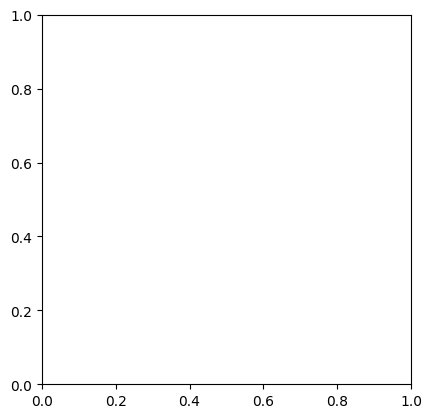

In [74]:
class RasterDrawing:
    def __init__(self, shapes=None):
        self.shapes = list(shapes) if shapes else []

    def add(self, shape):
        self.shapes.append(shape)

    def paint(self):
        canvas = Canvas()
        comp = CompoundShape(self.shapes)
        comp.paint(canvas)
        canvas.show()


d = RasterDrawing()
d.add(Rectangle(4,3,0,0))
d.add(Circle(1,2,1))
d.paint()

d.add(Triangle(0,0, 2,4, 4,0))
d.paint()

12. Implement the ability to load/save raster drawings and demonstate that your method works. One way to implement this ability:

   * Overload `__repr__` functions of all objects to return strings of the python code that would construct the object.
   
   * In the save method of raster drawing class, store the representations into the file.
   * Write a loader function that reads the file and uses `eval` to instantiate the object.

For example:

In [75]:
class Rectangle(Rectangle):
    def __repr__(self):
        return f"Rectangle({self.get_length()}, {self.get_width()}, {self.get_x()}, {self.get_y()})"

class Circle(Circle):
    def __repr__(self):
        return f"Circle({self.get_radius()}, {self.get_x()}, {self.get_y()})"

class Triangle(Triangle):
    def __repr__(self):
        p1,p2,p3 = self.get_points()
        return f"Triangle({p1[0]}, {p1[1]}, {p2[0]}, {p2[1]}, {p3[0]}, {p3[1]})"
        

In [ ]:
class RasterDrawing(RasterDrawing):
    def save(self, filename):
        with open(filename, "w") as f:
            for s in self.shapes:
                f.write(repr(s) + "\n")

    @staticmethod
    def load(filename):
        shapes = []
        with open(filename, "r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                # assignment expects eval
                shapes.append(eval(line))
        return RasterDrawing(shapes)


# demo save/load
d = RasterDrawing([Rectangle(4,3,0,0), Circle(1,2,1), Triangle(0,0,2,4,4,0)])
d.save("my_drawing.txt")

d2 = RasterDrawing.load("my_drawing.txt")
d2.paint()

In [6]:
class foo:
    def __init__(self,a,b=None):
        self.a=a
        self.b=b
        
    def __repr__(self):
        return "foo("+repr(self.a)+","+repr(self.b)+")"
    
    def save(self,filename):
        f=open(filename,"w")
        f.write(self.__repr__())
        f.close()
        
   
def foo_loader(filename):
    f=open(filename,"r")
    tmp=eval(f.read())
    f.close()
    return tmp


In [7]:
# Test
print(repr(foo(1,"hello")))

foo(1,'hello')


In [8]:
# Create an object and save it
ff=foo(1,"hello")
ff.save("Test.foo")

In [9]:
# Check contents of the saved file
!cat Test.foo

foo(1,'hello')

In [10]:
# Load the object
ff_reloaded=foo_loader("Test.foo")
ff_reloaded

foo(1,'hello')